## Exploratory Data Analysis

### Data quality check

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/germany_hypertension_public_health_2000_2019.csv")

df.head()
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Entity                                 20 non-null     object 
 1   Code                                   20 non-null     object 
 2   Year                                   20 non-null     int64  
 3   hypertension_prevalence                20 non-null     float64
 4   hypertension_women                     20 non-null     float64
 5   hypertension_men                       20 non-null     float64
 6   gender_gap_men_minus_women             20 non-null     float64
 7   hypertensive_heart_disease_death_rate  20 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 1.4+ KB


Index(['Entity', 'Code', 'Year', 'hypertension_prevalence',
       'hypertension_women', 'hypertension_men', 'gender_gap_men_minus_women',
       'hypertensive_heart_disease_death_rate'],
      dtype='object')

In [2]:
df.head()

,Entity,Code,Year,hypertension_prevalence,hypertension_women,hypertension_men,gender_gap_men_minus_women,hypertensive_heart_disease_death_rate
0,Germany,DEU,2000,40.2,34.9,45.5,10.6,7.579516
1,Germany,DEU,2001,39.6,34.3,44.9,10.6,7.771165
2,Germany,DEU,2002,39.0,33.7,44.3,10.6,8.414979
3,Germany,DEU,2003,38.5,33.1,43.8,10.7,9.315402
4,Germany,DEU,2004,37.9,32.5,43.2,10.7,9.446404


In [3]:
df.isna().sum()

Entity                                   0
Code                                     0
Year                                     0
hypertension_prevalence                  0
hypertension_women                       0
hypertension_men                         0
gender_gap_men_minus_women               0
hypertensive_heart_disease_death_rate    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,Year,hypertension_prevalence,hypertension_women,hypertension_men,gender_gap_men_minus_women,hypertensive_heart_disease_death_rate
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2009.50000,34.850000,29.645000,40.015000,10.370000,10.145271
std,5.91608,3.298564,3.108134,3.482328,0.444972,1.296666
min,2000.00000,29.700000,25.000000,34.400000,9.400000,7.579516
25%,2004.75000,32.075000,27.075000,37.150000,10.075000,9.634917
50%,2009.50000,34.900000,29.550000,40.200000,10.600000,9.933226
75%,2014.25000,37.525000,32.050000,42.825000,10.700000,11.267404
max,2019.00000,40.200000,34.900000,45.500000,10.800000,12.034011


In [6]:
# Columns 'Entity', 'Code' are not nessesary. Get rid of it.
analysis_df = df[
    [
        "Year",
        "hypertension_prevalence",
        "hypertension_women",
        "hypertension_men",
        "gender_gap_men_minus_women",
        "hypertensive_heart_disease_death_rate"
    ]
].copy()

analysis_df.head()

,Year,hypertension_prevalence,hypertension_women,hypertension_men,gender_gap_men_minus_women,hypertensive_heart_disease_death_rate
0,2000,40.2,34.9,45.5,10.6,7.579516
1,2001,39.6,34.3,44.9,10.6,7.771165
2,2002,39.0,33.7,44.3,10.6,8.414979
3,2003,38.5,33.1,43.8,10.7,9.315402
4,2004,37.9,32.5,43.2,10.7,9.446404


### Descriptive statistics

In [7]:
analysis_df.describe()

,Year,hypertension_prevalence,hypertension_women,hypertension_men,gender_gap_men_minus_women,hypertensive_heart_disease_death_rate
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2009.50000,34.850000,29.645000,40.015000,10.370000,10.145271
std,5.91608,3.298564,3.108134,3.482328,0.444972,1.296666
min,2000.00000,29.700000,25.000000,34.400000,9.400000,7.579516
25%,2004.75000,32.075000,27.075000,37.150000,10.075000,9.634917
50%,2009.50000,34.900000,29.550000,40.200000,10.600000,9.933226
75%,2014.25000,37.525000,32.050000,42.825000,10.700000,11.267404
max,2019.00000,40.200000,34.900000,45.500000,10.800000,12.034011


The dataset contains 20 annual observations for Germany from 2000 to 2019.
There are no missing values and no duplicated rows.
The dataset includes overall hypertension prevalence, sex-specific hypertension prevalence for women and men, the gender gap, and the hypertensive heart disease death rate.

Men had consistently higher hypertension prevalence than women during the observed period.
On average, the prevalence among men was about 10.37 percentage points higher than among women.

### Hypertension prevalence over time

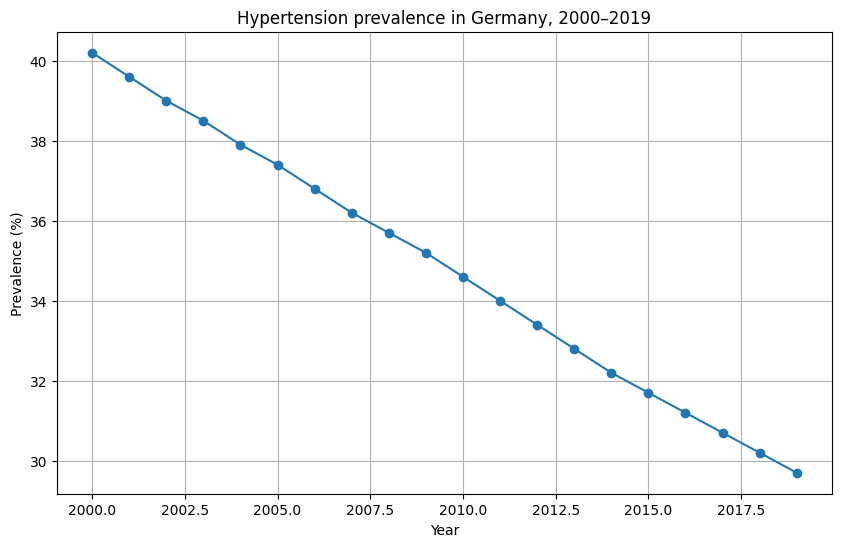

In [8]:
# First plot: prevalence of hypertension
plt.figure(figsize=(10, 6))

plt.plot(
    analysis_df["Year"],
    analysis_df["hypertension_prevalence"],
    marker="o"
)

plt.title("Hypertension prevalence in Germany, 2000–2019")
plt.xlabel("Year")
plt.ylabel("Prevalence (%)")
plt.grid(True)
plt.show()

Hypertension prevalence in Germany decreased steadily from 40.2% in 2000 to 29.7% in 2019. This indicates a clear downward trend over the observed period.

### Hypertension prevalence by sex

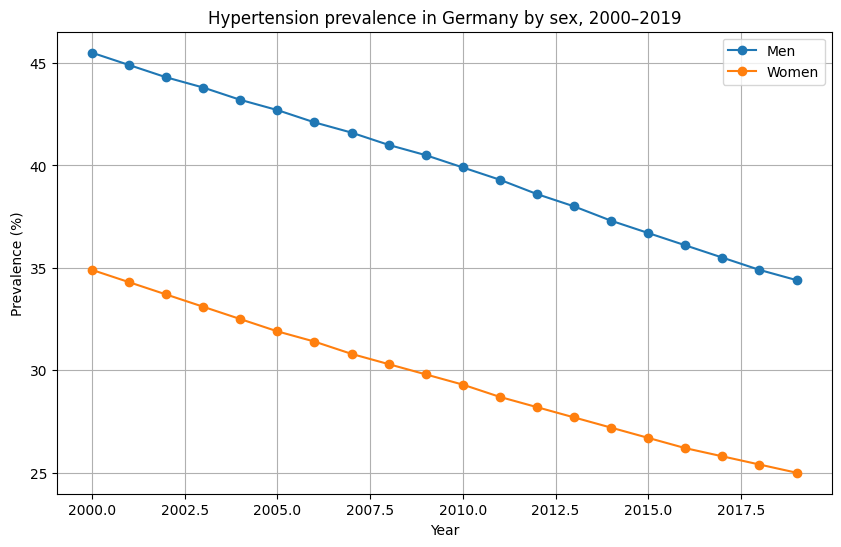

In [9]:
# Second plot: men and women
plt.figure(figsize=(10, 6))

plt.plot(
    analysis_df["Year"],
    analysis_df["hypertension_men"],
    marker="o",
    label="Men"
)

plt.plot(
    analysis_df["Year"],
    analysis_df["hypertension_women"],
    marker="o",
    label="Women"
)

plt.title("Hypertension prevalence in Germany by sex, 2000–2019")
plt.xlabel("Year")
plt.ylabel("Prevalence (%)")
plt.legend()
plt.grid(True)
plt.show()

Both men and women showed a continuous decline in hypertension prevalence between 2000 and 2019. However, prevalence was consistently higher among men than among women throughout the entire period.

In 2000, hypertension prevalence was 45.5% among men and 34.9% among women. By 2019, it decreased to 34.4% among men and 25.0% among women.

### Gender gap in hypertension prevalence

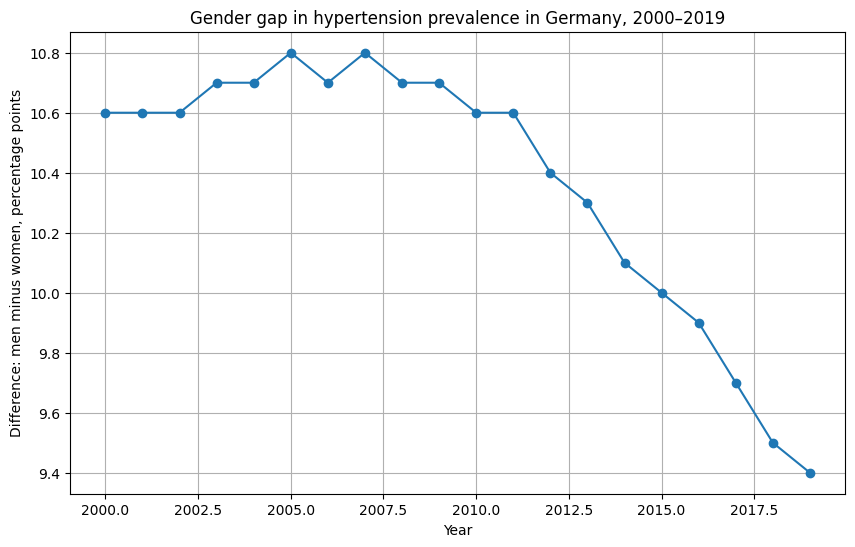

In [10]:
# Third plot: gender gap
plt.figure(figsize=(10, 6))

plt.plot(
    analysis_df["Year"],
    analysis_df["gender_gap_men_minus_women"],
    marker="o"
)

plt.title("Gender gap in hypertension prevalence in Germany, 2000–2019")
plt.xlabel("Year")
plt.ylabel("Difference: men minus women, percentage points")
plt.grid(True)
plt.show()

The gender gap, measured as the difference between male and female hypertension prevalence, remained around 10–11 percentage points in the early years. After 2011, the gap gradually decreased, reaching 9.4 percentage points in 2019.

### Hypertensive heart disease death rate

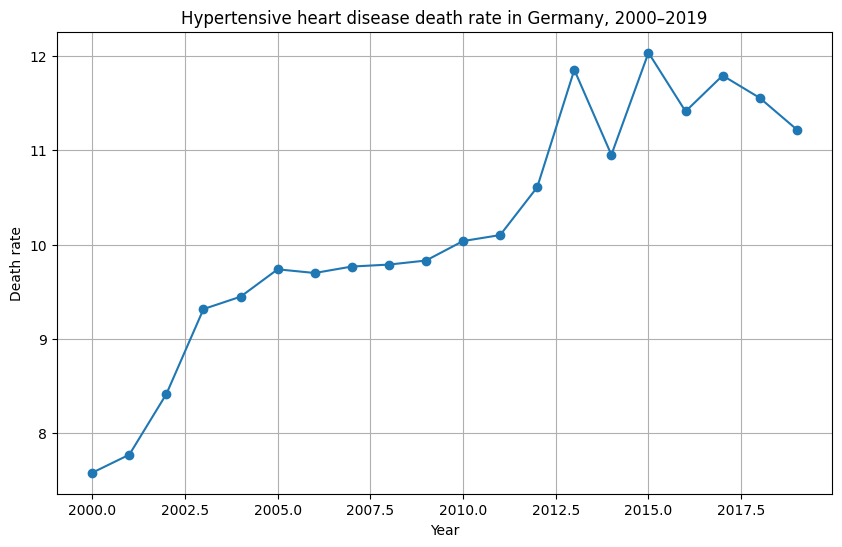

In [11]:
# Fourth plot: death rate
plt.figure(figsize=(10, 6))

plt.plot(
    analysis_df["Year"],
    analysis_df["hypertensive_heart_disease_death_rate"],
    marker="o"
)

plt.title("Hypertensive heart disease death rate in Germany, 2000–2019")
plt.xlabel("Year")
plt.ylabel("Death rate")
plt.grid(True)
plt.show()

In contrast to the decreasing hypertension prevalence, the hypertensive heart disease death rate increased from 7.58 in 2000 to a peak of 12.03 in 2015. After 2015, the death rate slightly declined but remained higher than at the beginning of the period.

Although hypertension prevalence decreased, the death rate related to hypertensive heart disease increased over much of the same period.

This suggests that hypertension-related mortality may be influenced by additional factors beyond prevalence alone, such as population ageing, disease management, comorbidities, and long-term cardiovascular complications.

### Correlation analysis

In [12]:
correlation_matrix = analysis_df.corr(numeric_only=True)

correlation_matrix

,Year,hypertension_prevalence,hypertension_women,hypertension_men,gender_gap_men_minus_women,hypertensive_heart_disease_death_rate
Year,1.000000,-0.999793,-0.998794,-0.999533,-0.845707,0.930408
hypertension_prevalence,-0.999793,1.000000,0.999177,0.999350,0.841593,-0.934207
hypertension_women,-0.998794,0.999177,1.000000,0.997322,0.819975,-0.939618
hypertension_men,-0.999533,0.999350,0.997322,1.000000,0.859645,-0.929235
gender_gap_men_minus_women,-0.845707,0.841593,0.819975,0.859645,1.000000,-0.708903
hypertensive_heart_disease_death_rate,0.930408,-0.934207,-0.939618,-0.929235,-0.708903,1.000000


Year vs hypertension_prevalence: -0.999793  ->  Hypertension prevalence strongly decreased over time between 2000 and 2019.

Year vs hypertensive_heart_disease_death_rate: 0.930408  ->  The hypertensive heart disease death rate increased over time, although the trend was less smooth than the decline in prevalence.

hypertension_prevalence vs hypertensive_heart_disease_death_rate: -0.934207  ->  Overall hypertension prevalence and hypertensive heart disease death rate showed a strong negative correlation. However, this does not mean that lower prevalence causes higher mortality. Both variables changed strongly over time in opposite directions, so the correlation is likely influenced by their time trends.

hypertension_men vs hypertension_women: 0.997322  ->  Male and female hypertension prevalence followed very similar downward trends over the observed period.

gender_gap_men_minus_women vs hypertensive_heart_disease_death_rate: -0.708903  ->  The gender gap decreased while the hypertensive heart disease death rate increased, resulting in a negative correlation between these two indicators.

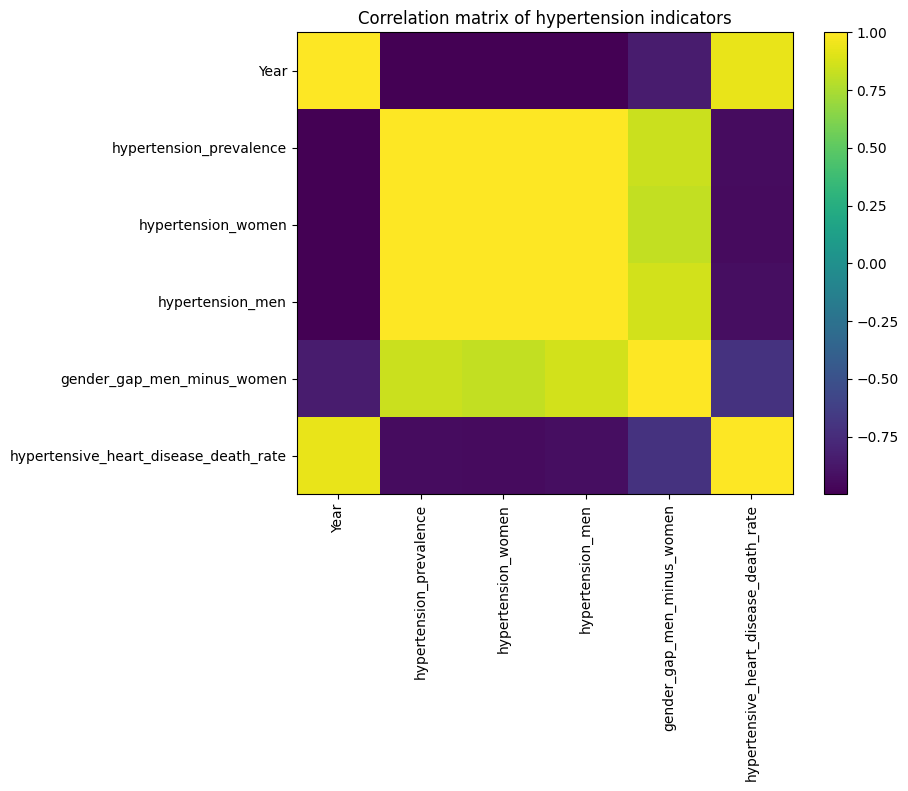

In [13]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation matrix of hypertension indicators")
plt.show()


The correlation matrix shows strong time-related patterns in the dataset. Hypertension prevalence was almost perfectly negatively correlated with year, indicating a steady decline between 2000 and 2019. In contrast, the hypertensive heart disease death rate was strongly positively correlated with year, showing that mortality increased over much of the same period.

Overall hypertension prevalence and hypertensive heart disease death rate showed a strong negative correlation. However, this result should be interpreted carefully. It does not imply that lower hypertension prevalence causes higher mortality. Instead, both indicators changed strongly over time but in opposite directions, which likely drives the observed correlation.

Male and female hypertension prevalence were very strongly positively correlated, meaning that both groups followed a similar downward trend. The gender gap also decreased over time, suggesting that the difference between men and women became slightly smaller by 2019.

Because the dataset contains only 20 annual observations and all indicators are time-dependent, the correlation analysis is descriptive and should not be interpreted as evidence of causality.

### Scatter plot: prevalence vs death rate

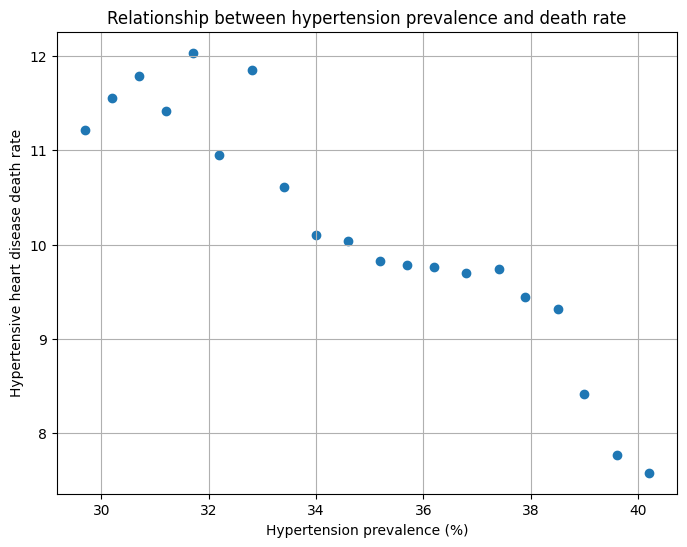

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["hypertension_prevalence"],
    analysis_df["hypertensive_heart_disease_death_rate"]
)

plt.title("Relationship between hypertension prevalence and death rate")
plt.xlabel("Hypertension prevalence (%)")
plt.ylabel("Hypertensive heart disease death rate")
plt.grid(True)
plt.show()

### Relationship between hypertension prevalence and death rate

The scatter plot shows a negative relationship between hypertension prevalence and the hypertensive heart disease death rate. Years with higher hypertension prevalence tend to have lower death rates, while years with lower prevalence tend to have higher death rates.

However, this relationship should be interpreted carefully. It does not mean that lower hypertension prevalence causes higher mortality. The pattern is mainly influenced by the time trend: hypertension prevalence decreased steadily from 2000 to 2019, while the death rate increased over much of the same period.

Therefore, the scatter plot supports the observation that the two indicators moved in opposite directions over time, but it does not provide evidence of causality.

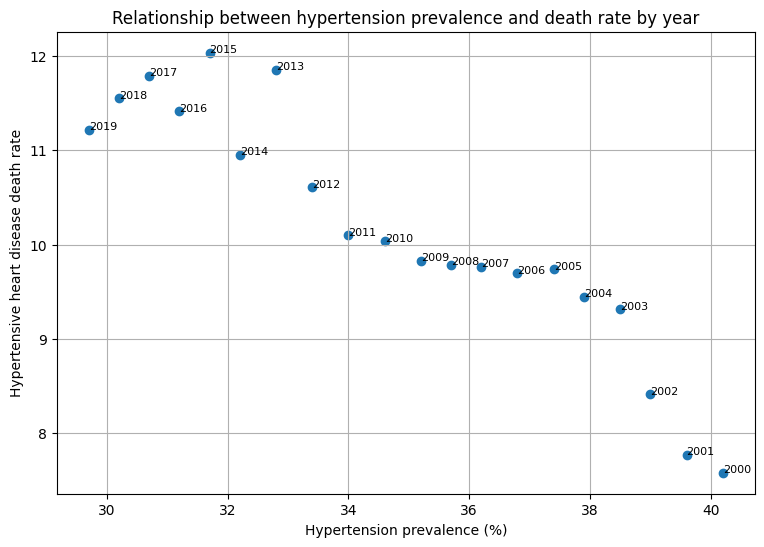

In [15]:
plt.figure(figsize=(9, 6))

plt.scatter(
    analysis_df["hypertension_prevalence"],
    analysis_df["hypertensive_heart_disease_death_rate"]
)

for i, year in enumerate(analysis_df["Year"]):
    plt.text(
        analysis_df["hypertension_prevalence"].iloc[i],
        analysis_df["hypertensive_heart_disease_death_rate"].iloc[i],
        str(year),
        fontsize=8
    )

plt.title("Relationship between hypertension prevalence and death rate by year")
plt.xlabel("Hypertension prevalence (%)")
plt.ylabel("Hypertensive heart disease death rate")
plt.grid(True)
plt.show()

### Key findings

The analysis shows that hypertension prevalence in Germany decreased steadily between 2000 and 2019. This decline was visible among both men and women, although prevalence remained consistently higher among men. The gender gap decreased slightly over time.

In contrast, the hypertensive heart disease death rate increased over much of the same period. Correlation analysis showed a strong negative relationship between hypertension prevalence and death rate, but this should not be interpreted as causality because both indicators are strongly influenced by time trends.